In [44]:
import cv2
import numpy as np


In [45]:
img1 = cv2.imread('./images/P1010378.JPG')
img2 = cv2.imread('./images/P1010379.JPG')


In [46]:
# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Use BFMatcher to find matches
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches by distance
matches = sorted(matches, key=lambda x: x.distance)
matches

[< cv2.DMatch 0x7645e5b70c50>,
 < cv2.DMatch 0x7645e5b71ef0>,
 < cv2.DMatch 0x7645e5fdf870>,
 < cv2.DMatch 0x7645e5b71770>,
 < cv2.DMatch 0x7645e5fdc7b0>,
 < cv2.DMatch 0x7645e5b71b70>,
 < cv2.DMatch 0x7645e5b71b90>,
 < cv2.DMatch 0x7645e5b71fb0>,
 < cv2.DMatch 0x7645e5b71c30>,
 < cv2.DMatch 0x7645e5b71af0>,
 < cv2.DMatch 0x7645e5b71fd0>,
 < cv2.DMatch 0x7645e5b71df0>,
 < cv2.DMatch 0x7645e5b71490>,
 < cv2.DMatch 0x7645e5b71f30>,
 < cv2.DMatch 0x7645e5b704b0>,
 < cv2.DMatch 0x7645e5b71730>,
 < cv2.DMatch 0x7645e5b71d50>,
 < cv2.DMatch 0x7645e5b71410>,
 < cv2.DMatch 0x7645e5b714f0>,
 < cv2.DMatch 0x7645e5fdc430>,
 < cv2.DMatch 0x7645e5b70970>,
 < cv2.DMatch 0x7645e5b71290>,
 < cv2.DMatch 0x7645e5b714b0>,
 < cv2.DMatch 0x7645e5b72830>,
 < cv2.DMatch 0x7645e5b718f0>,
 < cv2.DMatch 0x7645e5b712d0>,
 < cv2.DMatch 0x7645e5b71c70>,
 < cv2.DMatch 0x7645e5b70f30>,
 < cv2.DMatch 0x7645e5b71f10>,
 < cv2.DMatch 0x7645e5b718b0>,
 < cv2.DMatch 0x7645e5b727f0>,
 < cv2.DMatch 0x7645e5b70c90>,
 < cv2.D

In [47]:
img_matches = cv2.drawMatches(
    img1, kp1, img2, kp2, matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

cv2.namedWindow("output", cv2.WINDOW_NORMAL)    # Create window with freedom of dimensions
img_matches_resized = cv2.resize(img_matches, (1920, 1080))
cv2.imshow("local test", img_matches_resized)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [48]:
# Extract location of good matches
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# Compute homography
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
H


array([[ 1.02239771e+00,  3.28313613e-02, -2.07941721e+02],
       [-6.59152720e-02,  1.02782465e+00,  4.62894747e+02],
       [ 5.91614175e-06, -1.34191556e-06,  1.00000000e+00]])

In [49]:
import matplotlib.pyplot as plt
cv2.ocl.setUseOpenCL(False)

scale = 0.2

img1_small = cv2.resize(img1, None, fx=scale, fy=scale)
img2_small = cv2.resize(img2, None, fx=scale, fy=scale)


(np.float64(-0.5), np.float64(729.5), np.float64(546.5), np.float64(-0.5))

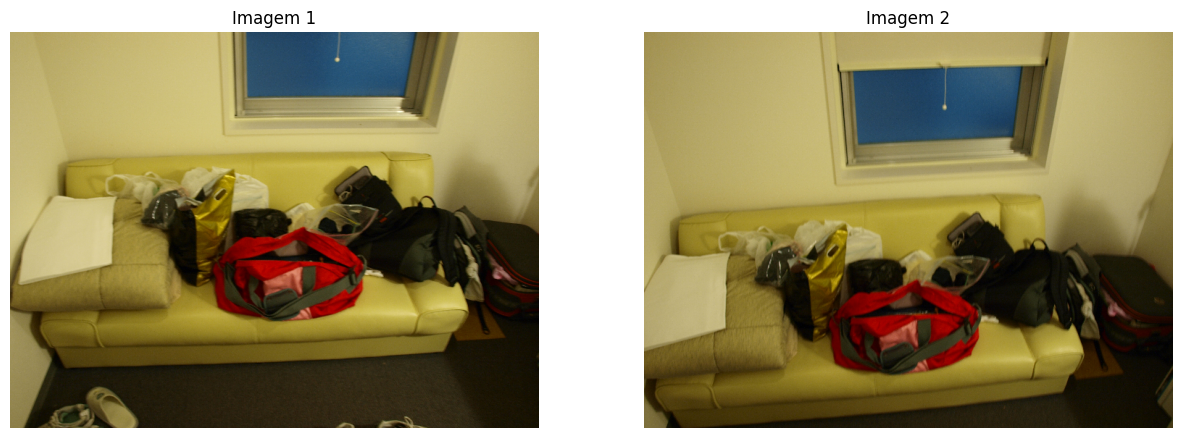

In [50]:
# mostrar imagens
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

ax[0].imshow(cv2.cvtColor(img1_small, cv2.COLOR_BGR2RGB))
ax[0].set_title("Imagem 1")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(img2_small, cv2.COLOR_BGR2RGB))
ax[1].set_title("Imagem 2")
ax[1].axis("off")


0


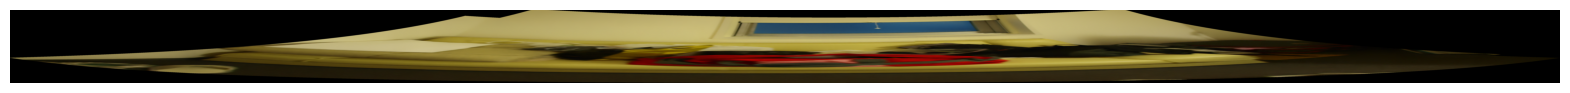

In [51]:
stitcher = cv2.Stitcher_create()

status, result = stitcher.stitch([img1_small, img2_small])

print(status)

if status == cv2.Stitcher_OK:
    plt.figure(figsize=(20,10))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
else:
    print("Erro no stitching")

## Com pipeline manual

In [52]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img2_small, None)
kp2, des2 = sift.detectAndCompute(img2_small, None)



In [53]:
bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

# pegar os melhores
matches = matches[:200]

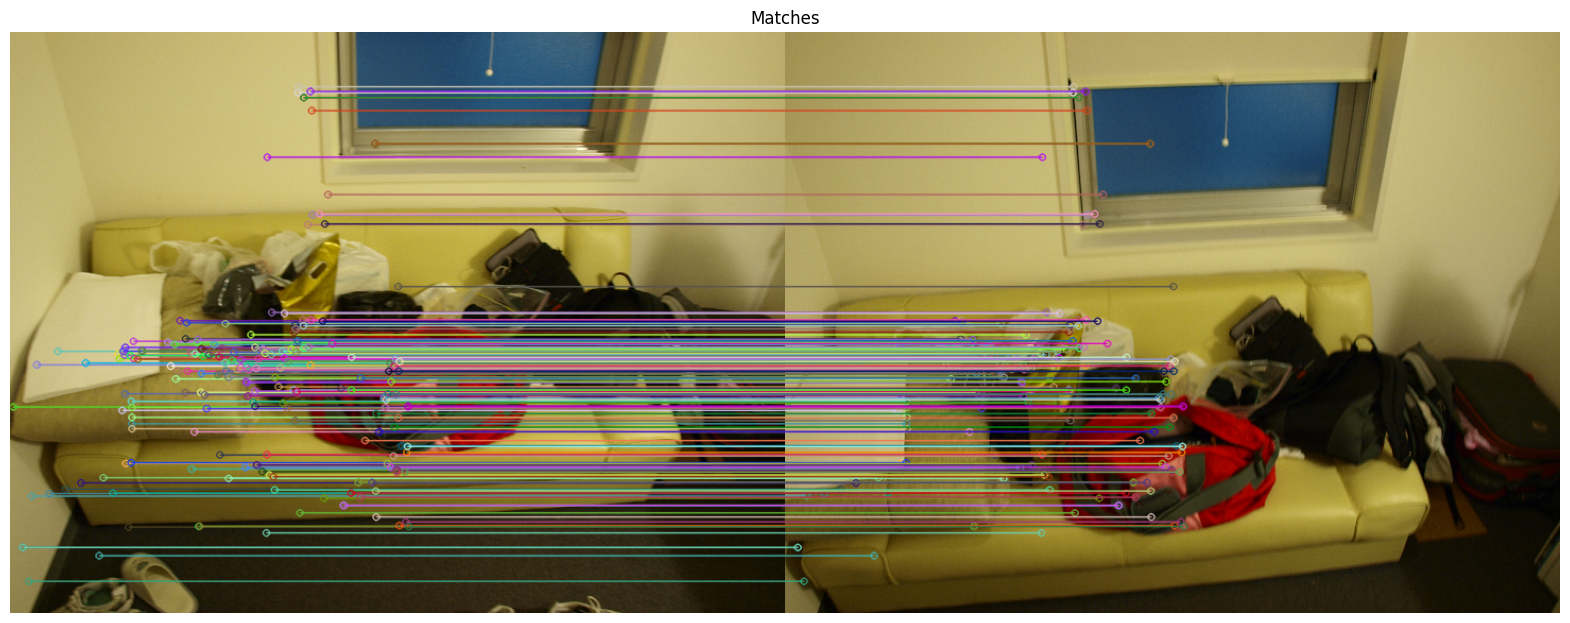

In [54]:
match_img = cv2.drawMatches(
    img1_small,
    kp1,
    img2_small,
    kp2,
    matches,
    None,
    flags=2
)

plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Matches")
plt.axis("off")
plt.show()

In [55]:
src_pts = np.float32([
    kp1[m.queryIdx].pt for m in matches
]).reshape(-1,1,2)

dst_pts = np.float32([
    kp2[m.trainIdx].pt for m in matches
]).reshape(-1,1,2)


In [56]:
img1_small = cv2.resize(img1, None, fx=scale, fy=scale)
img2_small = cv2.resize(img2, None, fx=scale, fy=scale)

gray1 = cv2.cvtColor(img1_small, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_small, cv2.COLOR_BGR2GRAY)

# =========================
# SIFT
# =========================
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# =========================
# MATCHING (knn)
# =========================
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print("Matches bons:", len(good))


Matches bons: 215


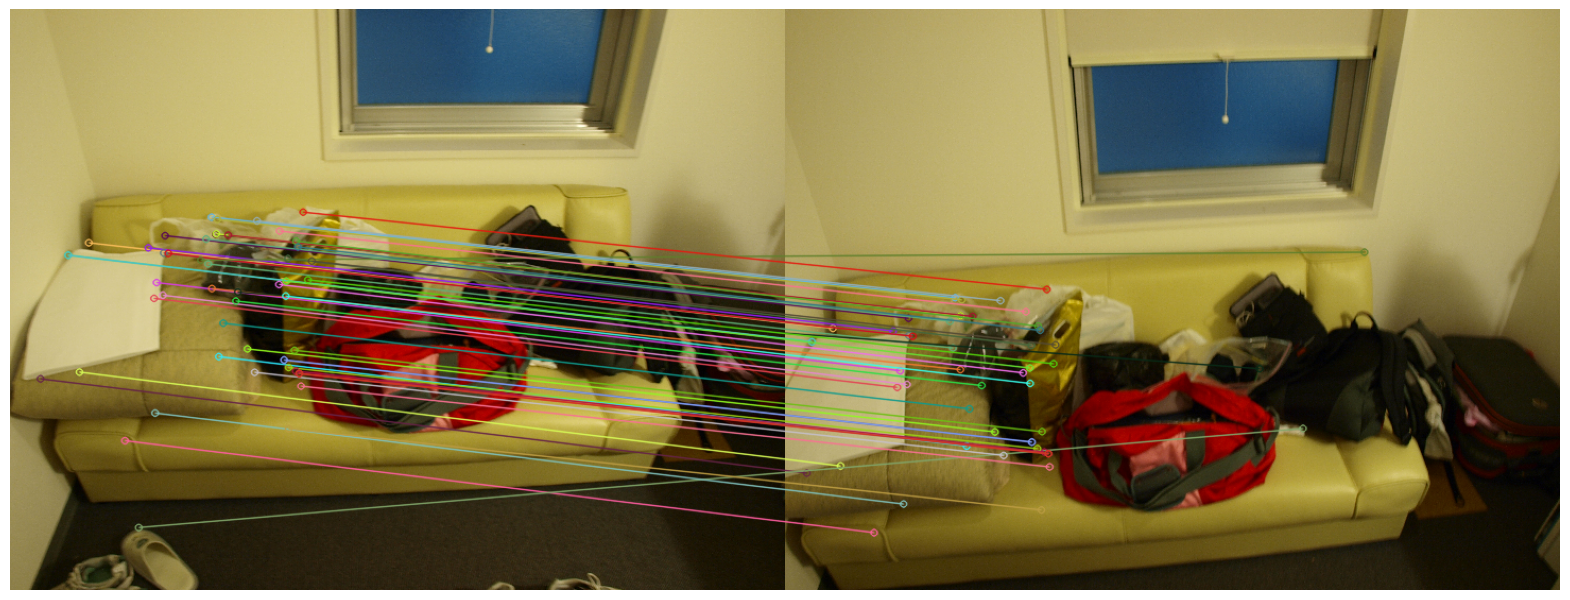

In [57]:
img_match = cv2.drawMatches(
    img1_small, kp1,
    img2_small, kp2,
    good[:50], None,
    flags=2
)

plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Matches bons: 199


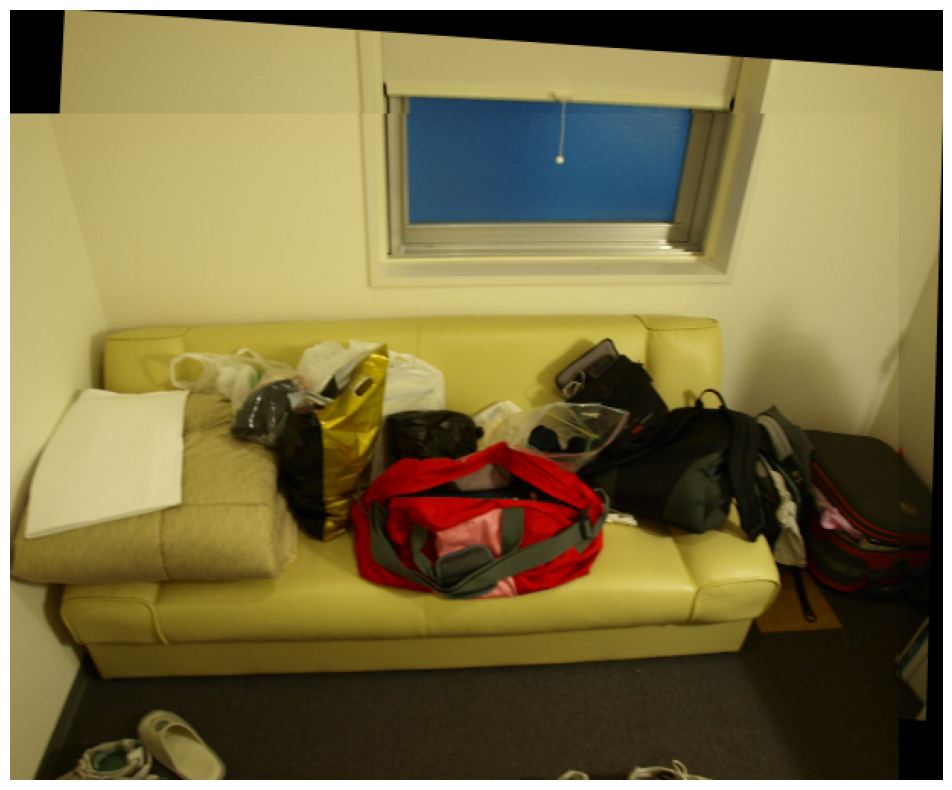

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

scale = 0.4

img1 = cv2.resize(img1, None, fx=scale, fy=scale)
img2 = cv2.resize(img2, None, fx=scale, fy=scale)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# =========================
# SIFT
# =========================
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print("Matches bons:", len(good))

if len(good) < 10:
    raise Exception("Poucos matches")

# =========================
# HOMOGRAFIA (img2 → img1)
# =========================
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

# =========================
# CANVAS MAIOR (evita corte)
# =========================
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

corners_img2 = np.float32([
    [0,0], [0,h2], [w2,h2], [w2,0]
]).reshape(-1,1,2)

transformed_corners = cv2.perspectiveTransform(corners_img2, H)

all_corners = np.concatenate((transformed_corners,
                              np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2)), axis=0)

[xmin, ymin] = np.int32(all_corners.min(axis=0).ravel())
[xmax, ymax] = np.int32(all_corners.max(axis=0).ravel())

translation = np.array([
    [1, 0, -xmin],
    [0, 1, -ymin],
    [0, 0, 1]
])

# =========================
# WARP + COMPOSIÇÃO CORRETA
# =========================
result = cv2.warpPerspective(img2, translation @ H, (xmax-xmin, ymax-ymin))

result[-ymin:h1-ymin, -xmin:w1-xmin] = img1

# =========================
# SHOW
# =========================
plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [37]:

H, mask = cv2.findHomography(
    dst_pts,
    src_pts,
    cv2.RANSAC,
    5.0
)

print("Homografia:")
print(H)


Homografia:
[[ 1.00000000e+00  2.22641685e-16 -4.19059243e-13]
 [ 1.23445920e-15  1.00000000e+00 -8.64553568e-13]
 [ 3.20548426e-18  2.57190256e-19  1.00000000e+00]]


In [38]:
h1, w1 = img1_small.shape[:2]
h2, w2 = img2_small.shape[:2]

canvas_width = w1 + w2
canvas_height = max(h1, h2)

result = cv2.warpPerspective(
    img1_small,
    H,
    (canvas_width, canvas_height)
)

# colocar img2 no canvas
result[0:h2, 0:w2] = img2_small

In [39]:
print(H)

[[ 1.00000000e+00  2.22641685e-16 -4.19059243e-13]
 [ 1.23445920e-15  1.00000000e+00 -8.64553568e-13]
 [ 3.20548426e-18  2.57190256e-19  1.00000000e+00]]


In [40]:
print(len(H))

3


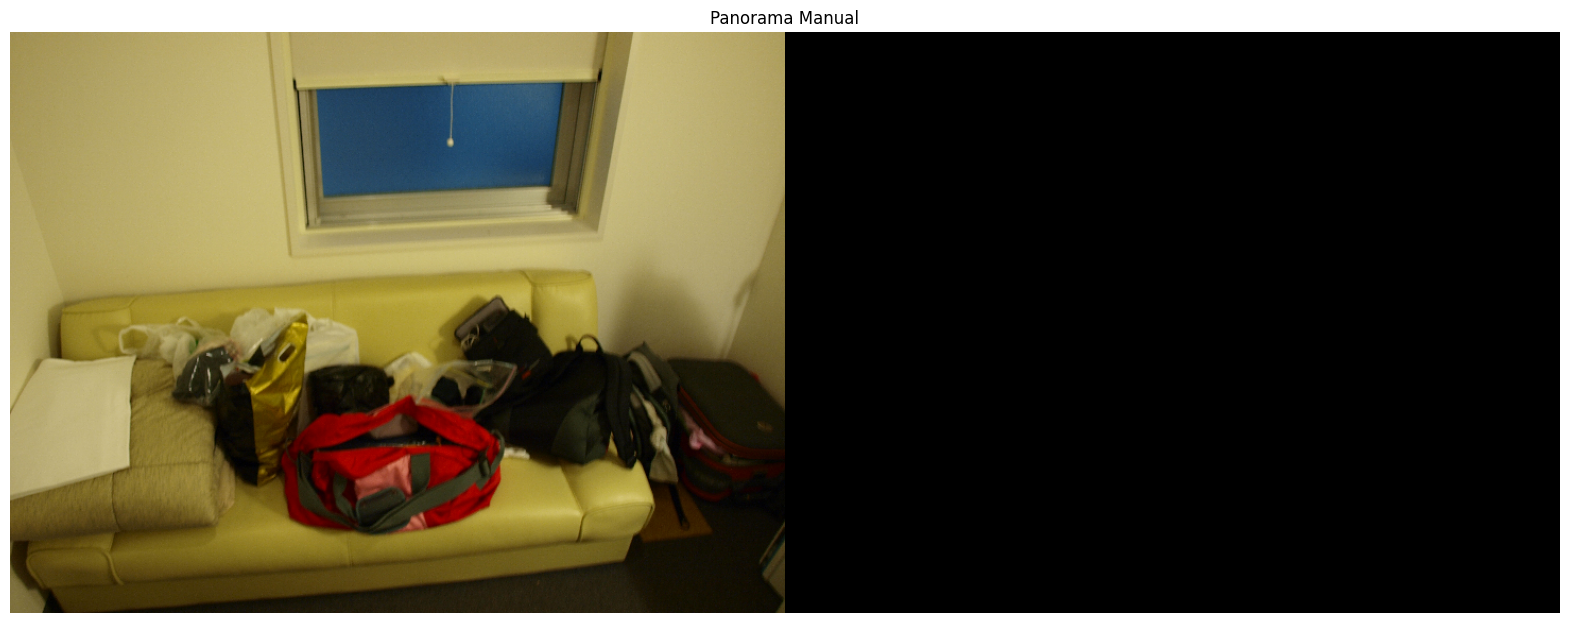

In [41]:
plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Panorama Manual")
plt.axis("off")
plt.show()

In [42]:
# # Get the dimensions of the images
# h1, w1 = img1.shape[:2]
# h2, w2 = img2.shape[:2]

# # Get the canvas dimesions
# pts = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
# dst = cv2.perspectiveTransform(pts, H)
# img2_warped = cv2.warpPerspective(img2, H, (w1 + w2, h1))

# # Place the first image on the canvas
# img2_warped[0:h1, 0:w1] = img1

In [43]:
# # Simple blending technique
# result = img2_warped
# result_resized = cv2.resize(result, (1920,1080))


# cv2.imshow('Result', result_resized)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


# Another try

Matches bons: 187


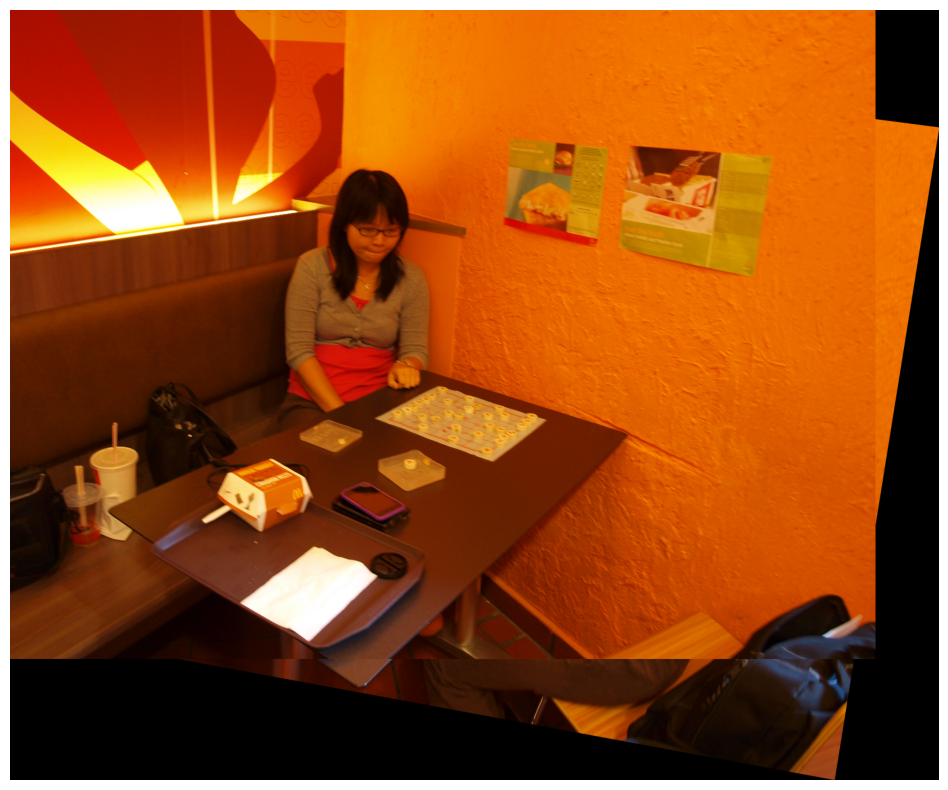

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('./images/P1011370.JPG')
img2 = cv2.imread('./images/P1011371.JPG')

scale = 0.4

img1 = cv2.resize(img1, None, fx=scale, fy=scale)
img2 = cv2.resize(img2, None, fx=scale, fy=scale)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# =========================
# SIFT
# =========================
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print("Matches bons:", len(good))

if len(good) < 10:
    raise Exception("Poucos matches")

# =========================
# HOMOGRAFIA (img2 → img1)
# =========================
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

# =========================
# CANVAS MAIOR (evita corte)
# =========================
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

corners_img2 = np.float32([
    [0,0], [0,h2], [w2,h2], [w2,0]
]).reshape(-1,1,2)

transformed_corners = cv2.perspectiveTransform(corners_img2, H)

all_corners = np.concatenate((transformed_corners,
                              np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2)), axis=0)

[xmin, ymin] = np.int32(all_corners.min(axis=0).ravel())
[xmax, ymax] = np.int32(all_corners.max(axis=0).ravel())

translation = np.array([
    [1, 0, -xmin],
    [0, 1, -ymin],
    [0, 0, 1]
])

# =========================
# WARP + COMPOSIÇÃO CORRETA
# =========================
result = cv2.warpPerspective(img2, translation @ H, (xmax-xmin, ymax-ymin))

result[-ymin:h1-ymin, -xmin:w1-xmin] = img1

# =========================
# SHOW
# =========================
plt.figure(figsize=(20,10))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
